In [1]:
import json
import numpy as np
import math
import matplotlib.pyplot as plt

In [2]:
from conformal_generation.sequence_selector import RunningMaxSequenceSelector, RunningSmallestSubsetSumSequenceSelector, PostprocessedSequenceSelector
#from conformal_generation.sequence_selector import SequenceSelectorFromScore
from conformal_generation.calibration_dataset import IndividualScoreCalibrationDataset
from conformal_generation.conformal_generation import ConformalGeneration

In [ ]:
#x_train = np.load('/home/path/Data/triviaqa/train/idx.npy', allow_pickle=True)
#x_test = np.load('/home/path/Data/triviaqa/test/idx.npy', allow_pickle=True)
data = []
for t in ["train", "test"]:
#for t in ['train']:
    x = np.load('./data/triviaqa/%s/idx.npy' % t, allow_pickle=True)
    success = (np.load('./data/triviaqa/%s/labels.npy' % t, allow_pickle=True) > 0.5).tolist()
    score = np.load('./data/triviaqa/%s/probs.npy' % t, allow_pickle=True)
    #evaluation = np.load('/home/path/Data/triviaqa/%s/self_eval.npy' % t, allow_pickle=True)

    
    for i in range(x.shape[0]):
        #print(i)
        dict_element = {}
        dict_element["name"] = str(int(x[i]))
        successi = [int(a) for a in success[i]]
        
        dict_element["success"] = successi
        l = []
        for j in range(20):
            answer = {}
            answer["completion"] = float(score[i,j]) #float(successi[j])
            answer["probability"] = float(score[i,j])
            answer["confidence"] = float(score[i,j])
            l.append(answer)        
        dict_element["interactions"] = l
        data.append(dict_element)
        if t == "train":
            idx = int(x.shape[0])
print(idx)
print(len(data))
print(data[0])
print(data[1])



2000
15944
{'name': '10458', 'success': [1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'interactions': [{'completion': 0.7154925499329796, 'probability': 0.7154925499329796, 'confidence': 0.7154925499329796}, {'completion': 0.417514242697702, 'probability': 0.417514242697702, 'confidence': 0.417514242697702}, {'completion': 0.149690994163353, 'probability': 0.149690994163353, 'confidence': 0.149690994163353}, {'completion': 0.3342096564603057, 'probability': 0.3342096564603057, 'confidence': 0.3342096564603057}, {'completion': 0.27541727308903297, 'probability': 0.27541727308903297, 'confidence': 0.27541727308903297}, {'completion': 0.04814430795684208, 'probability': 0.04814430795684208, 'confidence': 0.04814430795684208}, {'completion': 0.21255285165862106, 'probability': 0.21255285165862106, 'confidence': 0.21255285165862106}, {'completion': 0.41531164609688725, 'probability': 0.41531164609688725, 'confidence': 0.41531164609688725}, {'completion': 0.25851988095931583,

In [4]:
# load ground truth
truth = {}
# with open('../../data/dev_sample_self_eval.jsonl', 'r') as f:
with open('data/output.jsonl', 'r') as f:
    i = 0
    for line in f:
        item = json.loads(line)
        truth[str(i)] = item.copy()
        i += 1

In [5]:
def get_question_data(idx):
    if not isinstance(idx, str):
        idx = str(idx)
    return truth[idx]

def get_generated_answers(idx):
    if not isinstance(idx, str):
        idx = str(idx)
    return [generate["decoded"] for generate in truth[idx]["generations"]]

def get_unique_answers_idx(idx):
    if not isinstance(idx, str):
        idx = str(idx)
    gens = get_generated_answers(idx)
    uniq_gens = list(set(gens))
    return [gens.index(ug) for ug in uniq_gens]

def process_method(instance, outputs):
    unique_idx = get_unique_answers_idx(instance)
    process_outputs = [outputs[i] for i in unique_idx if i < len(outputs)]
    return process_outputs

In [12]:
admissibility_aggregation = lambda a_list: max(a_list) if len(a_list) > 0 else 1
score_fn = lambda x, y: y.get("completion", 0)
# score_fn = lambda x, y: np.mean([step["probability"] for step in y]) if len(y) > 0 else 0
sequence_selector = PostprocessedSequenceSelector(
    base_selector=RunningMaxSequenceSelector(score_fn=score_fn),
    process_method=process_method,
    returns_subsequence=True,
)
x = [(row["name"]) for row in data]
y = [row["interactions"] for row in data]
print(y[0])
for row_data, row_y in zip(data, y):
    for j, seq in enumerate(row_y):
        seq["success"] = row_data["success"][j]
        #for step in seq:
        #    step["success"] = row_data["success"][j]
#idx = int(0.8 * len(x))
x_train, x_test = x[:idx], x[idx:]
y_train, y_test = y[:idx], y[idx:]
#print(len(x_train))
a_data = [row["success"] for row in data]
a_train, a_test = a_data[:idx], a_data[idx:]
n = len(x_train)
calibration_ds = IndividualScoreCalibrationDataset(
    sequence_selector=sequence_selector,
    input_dataset=x_train,
    raw_generated_dataset=y_train,
    admissibility_dataset=a_train,
    admissibility_aggregation=admissibility_aggregation,
)
CG = ConformalGeneration(
    sequence_selector=sequence_selector,
    calibration_dataset=calibration_ds,
)
gamma0 = 0.7
CG.calibrate(gamma=gamma0, recalibrate=True)
selected= CG.select(instance=x_train[0], raw_generated_sequence=y_train[0])
print(CG._conformal_threshold)
print(sum(admissibility_aggregation([item['success'] for item in selected]) for selected in [CG.select(instance=x, raw_generated_sequence=y) for x, y in zip(x_train, y_train)]) / len(x_train))
print((len(x_train) + 1 ) * gamma0 / len(x_train))

# print(x_train)
# print(y_train)
# print([[step[-1]['completion'] for step in y] for y in y_train])
# print(a_train)



[{'completion': 0.7154925499329796, 'probability': 0.7154925499329796, 'confidence': 0.7154925499329796, 'success': 1}, {'completion': 0.417514242697702, 'probability': 0.417514242697702, 'confidence': 0.417514242697702, 'success': 0}, {'completion': 0.149690994163353, 'probability': 0.149690994163353, 'confidence': 0.149690994163353, 'success': 1}, {'completion': 0.3342096564603057, 'probability': 0.3342096564603057, 'confidence': 0.3342096564603057, 'success': 0}, {'completion': 0.27541727308903297, 'probability': 0.27541727308903297, 'confidence': 0.27541727308903297, 'success': 1}, {'completion': 0.04814430795684208, 'probability': 0.04814430795684208, 'confidence': 0.04814430795684208, 'success': 0}, {'completion': 0.21255285165862106, 'probability': 0.21255285165862106, 'confidence': 0.21255285165862106, 'success': 0}, {'completion': 0.41531164609688725, 'probability': 0.41531164609688725, 'confidence': 0.41531164609688725, 'success': 0}, {'completion': 0.25851988095931583, 'prob

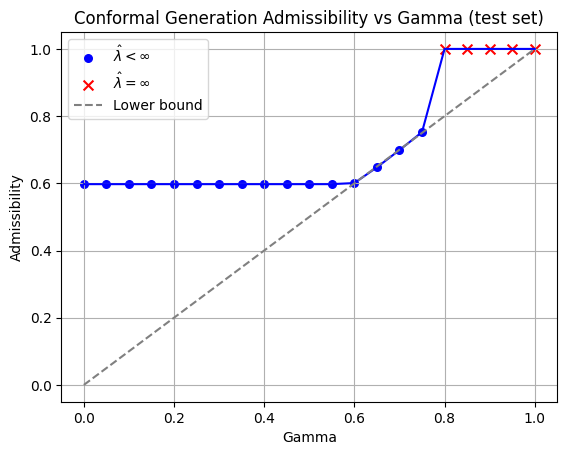

In [7]:
gamma_list = np.linspace(0, 1, 21).tolist()
results = {gamma: [] for gamma in gamma_list}
is_gamma_inf = {gamma: False for gamma in gamma_list}
seq_length = {gamma: [] for gamma in gamma_list}
for gamma in gamma_list:
    CG.calibrate(gamma=gamma, recalibrate=True)
    if CG._conformal_threshold == math.inf:
        is_gamma_inf[gamma] = True
        results[gamma] = [1 for _ in range(len(x_test))]
        seq_length[gamma] = [len(y_tmp) for y_tmp in y_test]
        continue
    for i in range(len(x_test)):
        selected = CG.select(instance=x_test[i], raw_generated_sequence=y_test[i])
        results[gamma].append(admissibility_aggregation([item['success'] for item in selected]))
        seq_length[gamma].append(len(selected))
est = [np.mean(results[gamma]) for gamma in gamma_list]
for gamma, y_val in zip(gamma_list, est):
    if is_gamma_inf[gamma]:
        plt.scatter(gamma, y_val, marker="x", color="red", s=50)
    else:
        plt.scatter(gamma, y_val, marker="o", color="blue", s=30)

#n_test = len(x_test)
# Add legend entries
plt.scatter([], [], marker="o", color="blue", label=r"$\hat{\lambda} < \infty$", s=30)
plt.scatter([], [], marker="x", color="red", label=r"$\hat{\lambda} = \infty$", s=50)
plt.plot(gamma_list, est, color="blue")
#plt.plot(gamma_list, gamma_list, linestyle="--", color="gray", label="Lower bound")
plt.plot(gamma_list, gamma_list, linestyle="--", color="gray", label="Lower bound")
plt.xlabel("Gamma")
plt.ylabel("Admissibility")
plt.title("Conformal Generation Admissibility vs Gamma (test set)")
plt.legend()
plt.grid()
plt.savefig("triviaqa_conformal_generation_admissibility_test_iid.pdf", format="pdf",bbox_inches='tight')
plt.show()



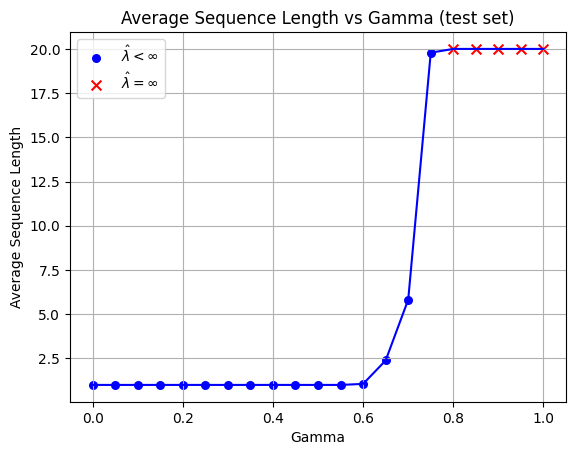

In [8]:
# plot average sequence length vs gamma
avg_seq_length = [np.mean(seq_length[gamma]) for gamma in gamma_list]
for gamma, val in zip(gamma_list, avg_seq_length):
    if is_gamma_inf[gamma]:
        plt.scatter(gamma, val, marker="x", color="red", s=50)
    else:
        plt.scatter(gamma, val, marker="o", color="blue", s=30)
plt.scatter([], [], marker="o", color="blue", label=r"$\hat{\lambda} < \infty$", s=30)
plt.scatter([], [], marker="x", color="red", label=r"$\hat{\lambda} = \infty$", s=50)
plt.plot(gamma_list, avg_seq_length, color="blue")
plt.xlabel("Gamma")
plt.ylabel("Average Sequence Length")
plt.title("Average Sequence Length vs Gamma (test set)")
plt.legend()
plt.grid()
plt.savefig("triviaqa_average_sequence_length_test_iid.pdf", format="pdf",bbox_inches='tight')
plt.show()

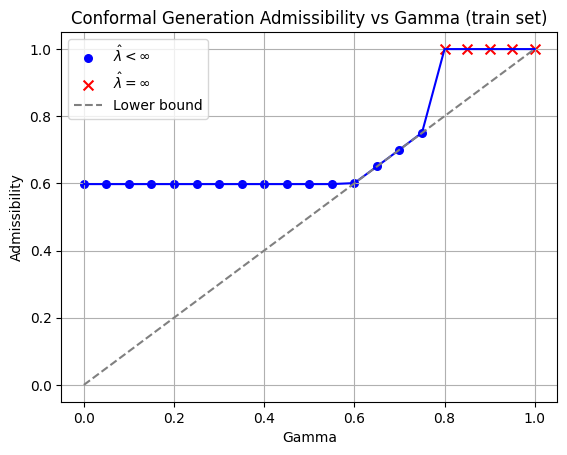

In [9]:
gamma_list = np.linspace(0, 1, 21).tolist()
results = {gamma: [] for gamma in gamma_list}
is_gamma_inf = {gamma: False for gamma in gamma_list}
seq_length = {gamma: [] for gamma in gamma_list}
for gamma in gamma_list:
    CG.calibrate(gamma=gamma, recalibrate=True)
    if CG._conformal_threshold == math.inf:
        is_gamma_inf[gamma] = True
        results[gamma] = [1 for _ in range(len(x_train))]
        seq_length[gamma] = [len(y_tmp) for y_tmp in y_train]
        continue
    for i in range(len(x_train)):
        selected = CG.select(instance=x_train[i], raw_generated_sequence=y_train[i])
        results[gamma].append(admissibility_aggregation([item['success'] for item in selected]))
        seq_length[gamma].append(len(selected))
est = [np.mean(results[gamma]) for gamma in gamma_list]
for gamma, y_val in zip(gamma_list, est):
    if is_gamma_inf[gamma]:
        plt.scatter(gamma, y_val, marker="x", color="red", s=50)
    else:
        plt.scatter(gamma, y_val, marker="o", color="blue", s=30)

# Add legend entries
plt.scatter([], [], marker="o", color="blue", label=r"$\hat{\lambda} < \infty$", s=30)
plt.scatter([], [], marker="x", color="red", label=r"$\hat{\lambda} = \infty$", s=50)
plt.plot(gamma_list, est, color="blue")
plt.plot(gamma_list, [g * (len(x_train) + 1) / len(x_train) for g in gamma_list], linestyle="--", color="gray", label="Lower bound")
plt.xlabel("Gamma")
plt.ylabel("Admissibility")
plt.title("Conformal Generation Admissibility vs Gamma (train set)")
plt.legend()
plt.grid()
plt.savefig("triviaqa_conformal_generation_admissibility_train_iid.pdf", format="pdf",bbox_inches='tight')
plt.show()


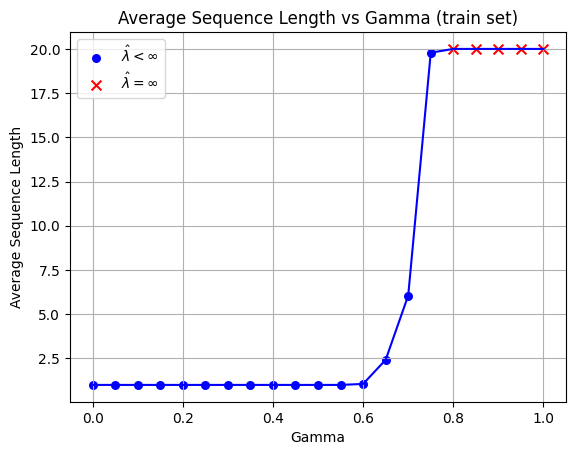

In [10]:
avg_seq_length = [np.mean(seq_length[gamma]) for gamma in gamma_list]
for gamma, val in zip(gamma_list, avg_seq_length):
    if is_gamma_inf[gamma]:
        plt.scatter(gamma, val, marker="x", color="red", s=50)
    else:
        plt.scatter(gamma, val, marker="o", color="blue", s=30)
plt.scatter([], [], marker="o", color="blue", label=r"$\hat{\lambda} < \infty$", s=30)
plt.scatter([], [], marker="x", color="red", label=r"$\hat{\lambda} = \infty$", s=50)
plt.plot(gamma_list, avg_seq_length, color="blue")
plt.xlabel("Gamma")
plt.ylabel("Average Sequence Length")
plt.title("Average Sequence Length vs Gamma (train set)")
plt.legend()
plt.grid()
plt.savefig("triviaqa_average_sequence_length_train_iid.pdf", format="pdf",bbox_inches='tight')
plt.show()